# Uncertainty Quantification

### 1. Loading Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm
import sys
import os

# --- 设置项目路径 ---
# 确保可以导入我们自己写的模块 (src目录下的文件)
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- 从我们自己的模块中导入 ---
from src import config
from src.dataset import create_data_loader
from src.model import SentimentClassifier
from transformers import DistilBertTokenizer

# --- 加载模型 ---
print("Loading the baseline model...")
device = torch.device(config.DEVICE)
model = SentimentClassifier(n_classes=config.N_CLASSES)
model_path = f"{config.SAVED_MODELS_PATH}/{config.SAVED_MODELS_NAME}"

# 加载已保存的状态字典
# 使用 map_location=device 确保模型被加载到正确的设备上
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval() # 切换到评估模式

# --- 加载分词器 ---
print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained(config.MODEL_NAME)

# 加载数据
print("Loading data...")
# --- 准备验证集数据 ---
val_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/validation.csv",
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)
# --- 准备测试集数据 ---
test_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/test.csv",
    tokenizer, 
    config.MAX_LEN,
    config.BATCH_SIZE
)
print("All loading completed!")

Uncertainty quantification method parameters have been successfully loaded.


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading the baseline model...
Loading tokenizer...
Loading data...
All loading completed!


___
### 2.Temperature Scaling

#### 2.1 Calculate the Optimal Temperature T Value

In [2]:
# 这是一个独立的诊断单元格
import torch.nn.functional as F

all_confidences = []
correct_predictions = 0
total_samples = 0

print("Calibrating the model before validation set evaluation...")
with torch.no_grad():
    for d in tqdm(val_data_loader, desc="Diagnosing Calibration"):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        
        # 1. 获取模型输出
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
        # 2. 计算概率和置信度
        probabilities = F.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)
        
        # 3. 收集所有置信度
        all_confidences.extend(confidences.cpu().numpy())
        
        # 4. 累加正确预测的数量和总样本数
        correct_predictions += torch.sum(predictions == labels).item()
        total_samples += len(labels)

# 5. 计算最终指标
average_confidence = np.mean(all_confidences)
accuracy = correct_predictions / total_samples

# --- 打印诊断结论 ---
print("\n" + "="*20 + " Pre-calibration Diagnostic Report " + "="*20)
print(f"The Actual Accuracy Rate: {accuracy:.4f}")
print(f"The Average Confidence:   {average_confidence:.4f}")

# 得出结论
print("\nConclusion:")
if average_confidence > accuracy:
    print("The model exhibits 'Overconfidence'.")
elif average_confidence < accuracy:
    print("The model exhibits 'Lack of Confidence'.")
else:
    print("The model has been calibrated well.")
print("="*64)

Calibrating the model before validation set evaluation...


Diagnosing Calibration: 100%|██████████| 156/156 [00:33<00:00,  4.71it/s]


==================== Pre-calibration Diagnostic Report ====================
The Actual Accuracy Rate: 0.8230
The Average Confidence:   0.8735

Conclusion:
The model exhibits 'Overconfidence'.


In [3]:
from src.uncertainty.temperature_scaling import find_optimal_temperature

# 1. 找到最优T
print("\nThe temperature parameter T is optimizing...")
optimal_temperature = find_optimal_temperature(model, val_data_loader, device)
# 保留四位小数四舍五入
short_temperature = round(optimal_temperature, 4)
# 更新参数列表
config.update_uq_params(temperature=short_temperature)
print(f"Optimization completed! Optimal temperature T = {short_temperature}")


The temperature parameter T is optimizing...
正在验证集上获取Logits...


Finding Optimal T: 100%|██████████| 156/156 [00:32<00:00,  4.81it/s]


UQ parameters have been successfully updated.
Optimization completed! Optimal temperature T = 1.2871


#### 2.2 Evaluate Calibration Effectiveness on the Test Set

In [4]:
# --- 准备测试集数据 ---
test_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/test.csv",
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)

# --- 在测试集上获取Logits和概率 ---
test_logits = []
test_labels = []
with torch.no_grad():
    for d in tqdm(test_data_loader, desc="Testing"):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        test_logits.append(logits)
        test_labels.append(labels)

test_logits = torch.cat(test_logits)
test_labels = torch.cat(test_labels)

# --- 计算校准前后的概率和置信度 ---
softmaxes = torch.softmax(test_logits, dim=1)
confidences, predictions = torch.max(softmaxes, 1)

# 使用最优温度进行校准
scaled_logits = test_logits / optimal_temperature
calibrated_softmaxes = torch.softmax(scaled_logits, dim=1)
calibrated_confidences, _ = torch.max(calibrated_softmaxes, 1)

# --- 打印结果对比 ---
print("\n--- 校准效果对比 ---")
print(f"校准前 (T=1.0) 的平均置信度: {confidences.mean().item():.4f}")
print(f"校准后 (T={optimal_temperature:.4f}) 的平均置信度: {calibrated_confidences.mean().item():.4f}")

# --- 计算准确率和F1分数 ---
accuracy = (predictions == test_labels).float().mean()

# --- 新增代码：计算加权F1分数 ---
# scikit-learn的函数需要NumPy数组，所以我们用 .cpu().numpy() 进行转换
y_true = test_labels.cpu().numpy()
y_pred = predictions.cpu().numpy()
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
# ---------------------------------

print("\n--- 最终性能评估 ---")
print(f"模型在测试集上的准确率: {accuracy.item():.4f} (此值不应受温度影响)")
# --- 新增代码：打印F1分数 ---
print(f"模型在测试集上的加权F1分数: {weighted_f1:.4f} (此值不应受温度影响)")

Testing: 100%|██████████| 156/156 [00:32<00:00,  4.80it/s]


--- 校准效果对比 ---
校准前 (T=1.0) 的平均置信度: 0.8768
校准后 (T=1.2871) 的平均置信度: 0.8410

--- 最终性能评估 ---
模型在测试集上的准确率: 0.8165 (此值不应受温度影响)
模型在测试集上的加权F1分数: 0.8165 (此值不应受温度影响)


#### 2.3 Visualization

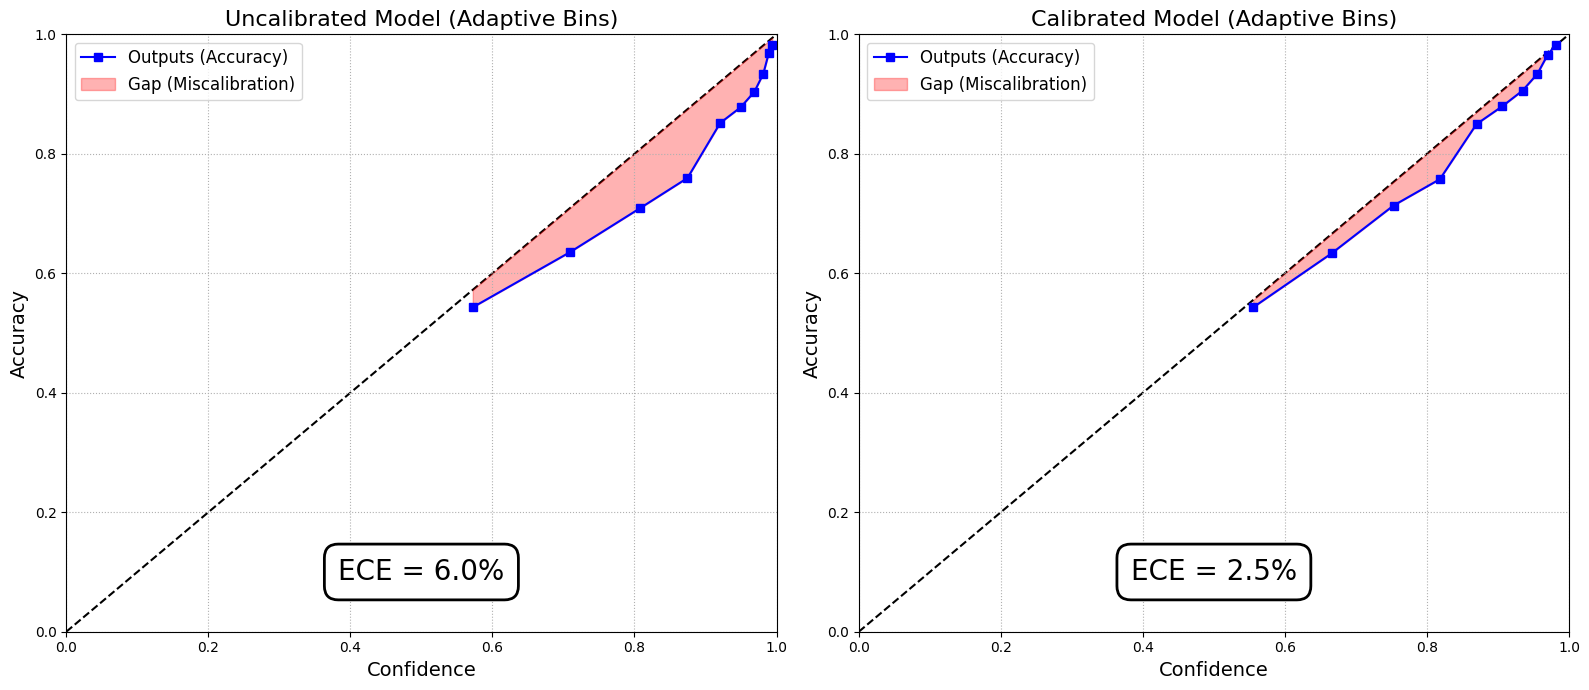

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. 修改后的ECE和绘图函数 (使用自适应分箱) ---
def calculate_ece_adaptive(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    
    # 按置信度排序
    sorted_indices = np.argsort(confidences)
    confidences = confidences[sorted_indices]
    accuracies = accuracies[sorted_indices]
    
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        
        bin_confidences = confidences[start_idx:end_idx]
        bin_accuracies = accuracies[start_idx:end_idx]
        
        if len(bin_confidences) > 0:
            avg_confidence = np.mean(bin_confidences)
            accuracy = np.mean(bin_accuracies)
            ece += np.abs(avg_confidence - accuracy)
            
    return (ece / n_bins) * 100

def plot_reliability_diagram_adaptive(ax, probs, labels, title):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    n_bins = 10

    # 按置信度排序
    sorted_indices = np.argsort(confidences)
    confidences = confidences[sorted_indices]
    accuracies = accuracies[sorted_indices]
    
    samples_per_bin = len(confidences) / n_bins
    
    bin_avg_conf = []
    bin_accuracy = []
    
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        
        bin_confidences = confidences[start_idx:end_idx]
        bin_accuracies = accuracies[start_idx:end_idx]
        
        if len(bin_confidences) > 0:
            bin_avg_conf.append(np.mean(bin_confidences))
            bin_accuracy.append(np.mean(bin_accuracies))

    ece = calculate_ece_adaptive(probs, labels, n_bins)

    ax.plot([0, 1], [0, 1], 'k--', zorder=1)
    
    # 绘制折线图，因为箱子宽度不一，用折线图更合适
    ax.plot(bin_avg_conf, bin_accuracy, 's-', color='blue', label='Outputs (Accuracy)', zorder=2)
    
    # 填充Gap
    y_upper = np.maximum(bin_accuracy, bin_avg_conf)
    y_lower = np.minimum(bin_accuracy, bin_avg_conf)
    ax.fill_between(bin_avg_conf, y_lower, y_upper, color='red', alpha=0.3, label='Gap (Miscalibration)', zorder=1)

    ax.set_xlabel('Confidence', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='dotted')
    
    ax.text(0.5, 0.1, f'ECE = {ece:.1f}%', 
            ha='center', va='center', fontsize=20, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=2))

    ax.legend(loc='upper left', fontsize=12)

# --- 2. 创建子图并调用新的绘图函数 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 绘制校准前的图
plot_reliability_diagram_adaptive(
    axes[0],
    softmaxes.cpu().numpy(),
    y_true,
    "Uncalibrated Model (Adaptive Bins)"
)

# 绘制校准后的图
plot_reliability_diagram_adaptive(
    axes[1],
    calibrated_softmaxes.cpu().numpy(),
    y_true,
    "Calibrated Model (Adaptive Bins)"
)

plt.tight_layout()
plt.show()

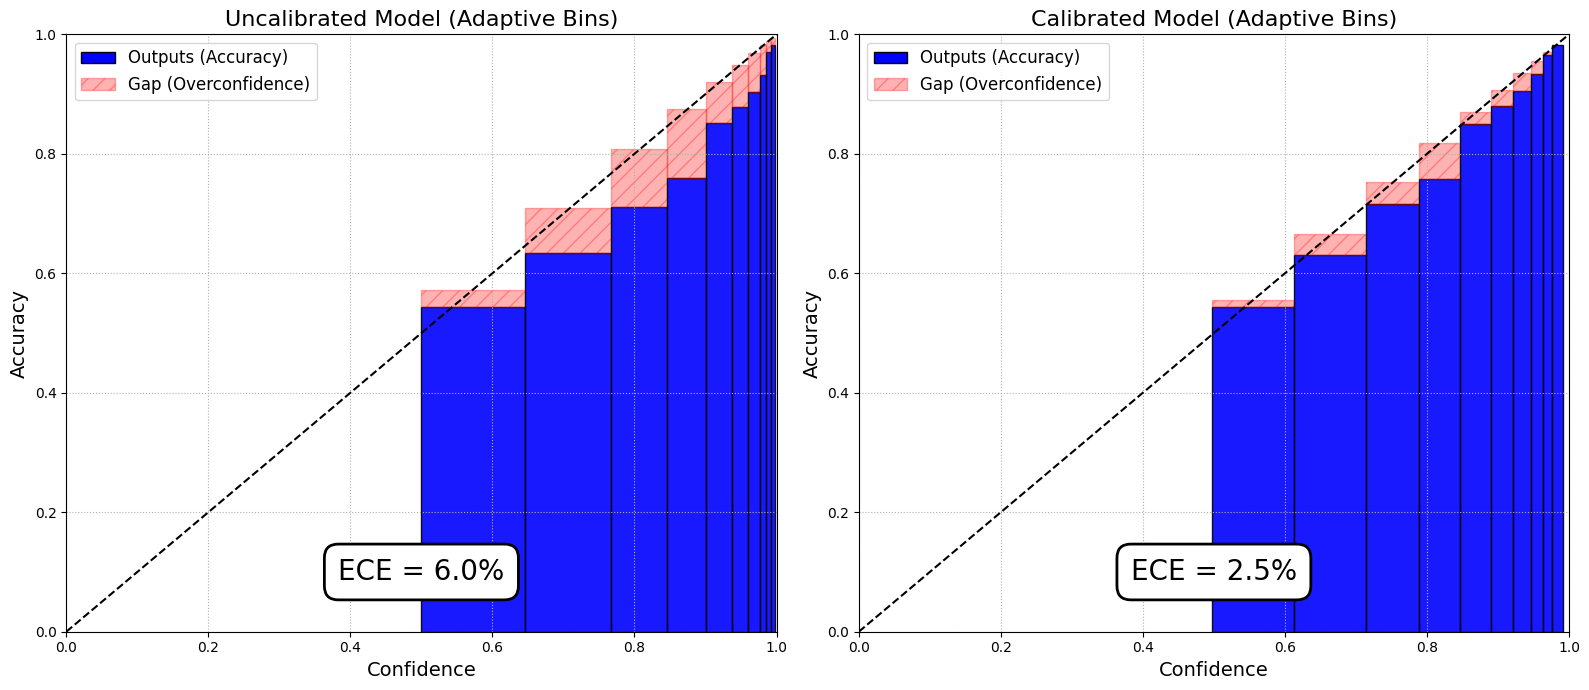

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 确保 softmaxes, calibrated_softmaxes, y_true 等变量已经存在

# --- 1. 定义计算 ECE 的函数 (使用自适应分箱) ---
def calculate_ece_adaptive(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    
    sorted_indices = np.argsort(confidences)
    confidences = confidences[sorted_indices]
    accuracies = accuracies[sorted_indices]
    
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        
        bin_confidences = confidences[start_idx:end_idx]
        bin_accuracies = accuracies[start_idx:end_idx]
        
        if len(bin_confidences) > 0:
            avg_confidence = np.mean(bin_confidences)
            accuracy = np.mean(bin_accuracies)
            ece += np.abs(avg_confidence - accuracy)
            
    return (ece / n_bins) * 100

# --- 2. 定义绘制最终版可靠性图的函数 (自适应分箱 + 柱状图) ---
def plot_reliability_diagram_final(ax, probs, labels, title):
    """在指定的matplotlib轴上绘制最终版的可靠性图"""
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    n_bins = 10
    
    # --- 核心修改：使用np.percentile来确定每个箱子的边界 ---
    # 这确保了每个箱子包含相同数量的样本 (10% of data)
    bin_boundaries = np.percentile(confidences, np.linspace(0, 100, n_bins + 1))
    
    ece = calculate_ece_adaptive(probs, labels, n_bins)

    ax.plot([0, 1], [0, 1], 'k--', zorder=2) # 绘制对角虚线

    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        # 对于第一个箱子，包含等于0的置信度
        if i == 0:
            in_bin = (confidences >= bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])

        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            
            # --- 核心修改：绘制不等宽的柱状图 ---
            bin_width = bin_boundaries[i+1] - bin_boundaries[i]
            bin_center = bin_boundaries[i] + bin_width / 2
            
            # 绘制蓝色柱子 (准确率)
            ax.bar(
                bin_center,
                accuracy_in_bin,
                width=bin_width,
                color='blue',
                edgecolor='black',
                alpha=0.9,
                zorder=1
            )
            
            # 绘制红色误差区域 (Gap)
            gap = avg_confidence_in_bin - accuracy_in_bin
            if gap > 0:
                ax.bar(
                    bin_center,
                    gap,
                    width=bin_width,
                    bottom=accuracy_in_bin,
                    color='red',
                    edgecolor='red',
                    alpha=0.3,
                    hatch='//',
                    zorder=1
                )
    
    # ... (其余的美化代码保持不变) ...
    ax.set_xlabel('Confidence', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='dotted')
    ax.text(0.5, 0.1, f'ECE = {ece:.1f}%', 
            ha='center', va='center', fontsize=20, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=2))
    output_patch = mpatches.Patch(facecolor='blue', edgecolor='black', label='Outputs (Accuracy)')
    gap_patch = mpatches.Patch(facecolor='red', edgecolor='red', alpha=0.3, hatch='//', label='Gap (Overconfidence)')
    ax.legend(handles=[output_patch, gap_patch], loc='upper left', fontsize=12)

# --- 3. 创建子图并调用新的绘图函数 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 绘制校准前的图
plot_reliability_diagram_final(
    axes[0],
    softmaxes.cpu().numpy(),
    y_true,
    "Uncalibrated Model (Adaptive Bins)"
)

# 绘制校准后的图
plot_reliability_diagram_final(
    axes[1],
    calibrated_softmaxes.cpu().numpy(),
    y_true,
    "Calibrated Model (Adaptive Bins)"
)

plt.tight_layout()
plt.show()

___
### 3.MC Dropout

#### 3.1 Activate dropout

In [7]:
# --- 1. 从您创建的模块中导入函数 ---
from src.uncertainty.mc_dropout import get_mc_dropout_predictions
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# --- 2. 运行MC Dropout ---
N_SAMPLES = config.get_uq_param('mc_sampling_times') # 设置采样次数
mc_results = get_mc_dropout_predictions(model, test_data_loader, N_SAMPLES, device)

# --- 3. 计算传统性能指标 ---
mc_accuracy = np.mean(mc_results['predictions'] == mc_results['labels'])
mc_f1 = f1_score(mc_results['labels'], mc_results['predictions'], average='weighted', zero_division=0)

print("\n--- MC Dropout 性能评估 ---")
print(f"模型在测试集上的准确率: {mc_accuracy:.4f}")
print(f"模型在测试集上的加权F1分数: {mc_f1:.4f}")

MC Dropout (N=10): 100%|██████████| 156/156 [03:33<00:00,  1.37s/it]



--- MC Dropout 性能评估 ---
模型在测试集上的准确率: 0.8181
模型在测试集上的加权F1分数: 0.8180


#### 3.2 Visualization

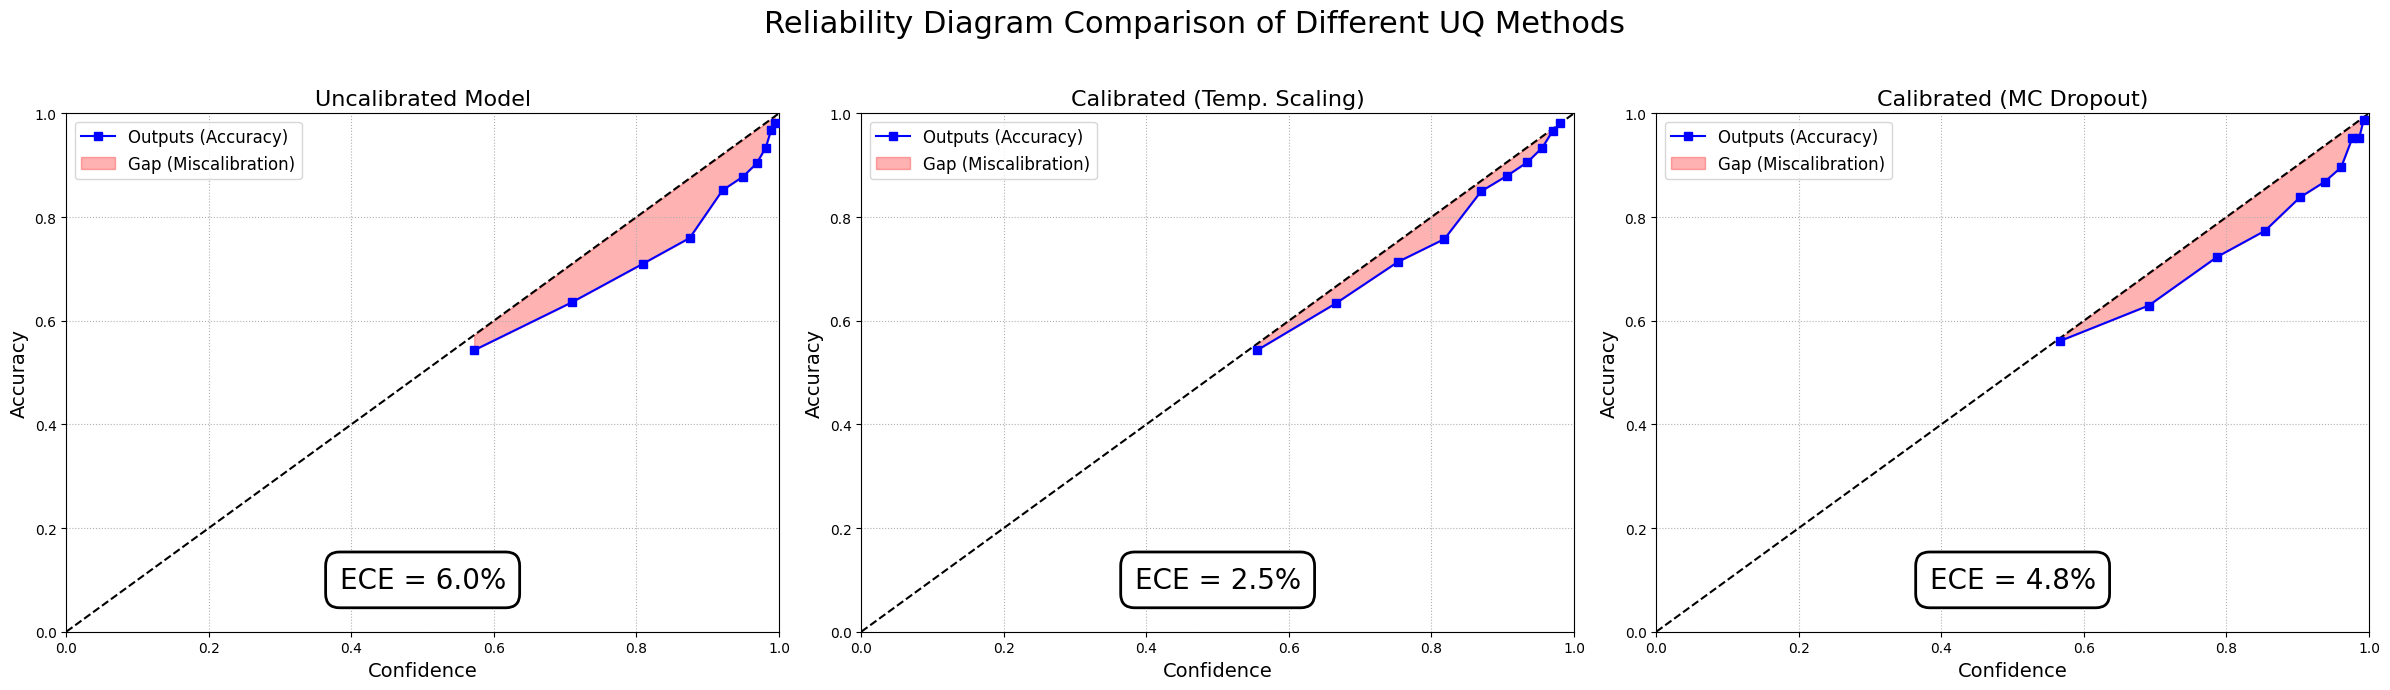

In [8]:
import torch
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 确保以下变量已经从之前的单元格计算得出 ---
# softmaxes: 校准前模型的原始概率输出 (numpy array)
# calibrated_softmaxes: 温度缩放校准后的概率输出 (numpy array)
# mc_results: 运行MC Dropout后得到的完整结果字典
# y_true: 真实的标签 (numpy array)

# --- 1. 绘图函数 (与之前相同，此处重定义以保证单元格独立性) ---

def calculate_ece_adaptive(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_confidences, bin_accuracies = confidences[start_idx:end_idx], accuracies[start_idx:end_idx]
        avg_confidence = np.mean(bin_confidences)
        accuracy = np.mean(bin_accuracies)
        ece += np.abs(avg_confidence - accuracy)
    return (ece / n_bins) * 100

def plot_reliability_diagram_adaptive(ax, probs, labels, title):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    n_bins = 10
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    samples_per_bin = len(confidences) / n_bins
    bin_avg_conf, bin_accuracy = [], []
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_avg_conf.append(np.mean(confidences[start_idx:end_idx]))
        bin_accuracy.append(np.mean(accuracies[start_idx:end_idx]))
    
    ece = calculate_ece_adaptive(probs, labels, n_bins)
    ax.plot([0, 1], [0, 1], 'k--', zorder=2)
    ax.plot(bin_avg_conf, bin_accuracy, 's-', color='blue', label='Outputs (Accuracy)', zorder=3)
    y_upper = np.maximum(bin_accuracy, bin_avg_conf)
    y_lower = np.minimum(bin_accuracy, bin_avg_conf)
    ax.fill_between(bin_avg_conf, y_lower, y_upper, color='red', alpha=0.3, label='Gap (Miscalibration)', zorder=1)
    ax.set_xlabel('Confidence', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='dotted')
    ax.text(0.5, 0.1, f'ECE = {ece:.1f}%', ha='center', va='center', fontsize=20, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=2))
    ax.legend(loc='upper left', fontsize=12)

# --- 2. 创建一个1x3的子图布局，用于并排比较 ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- 图一：绘制未校准模型的可靠性图 ---
plot_reliability_diagram_adaptive(
    axes[0],
    softmaxes.cpu().numpy(), # 基线模型的概率
    y_true,
    "Uncalibrated Model"
)

# --- 图二：绘制温度缩放校准后的可靠性图 ---
plot_reliability_diagram_adaptive(
    axes[1],
    calibrated_softmaxes.cpu().numpy(), # 温度缩放的概率
    y_true,
    "Calibrated (Temp. Scaling)"
)

# --- 图三：绘制MC Dropout校准后的可靠性图 ---
plot_reliability_diagram_adaptive(
    axes[2],
    mc_results['mean_probs'], # MC Dropout的平均概率
    mc_results['labels'],
    "Calibrated (MC Dropout)"
)

plt.suptitle("Reliability Diagram Comparison of Different UQ Methods", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

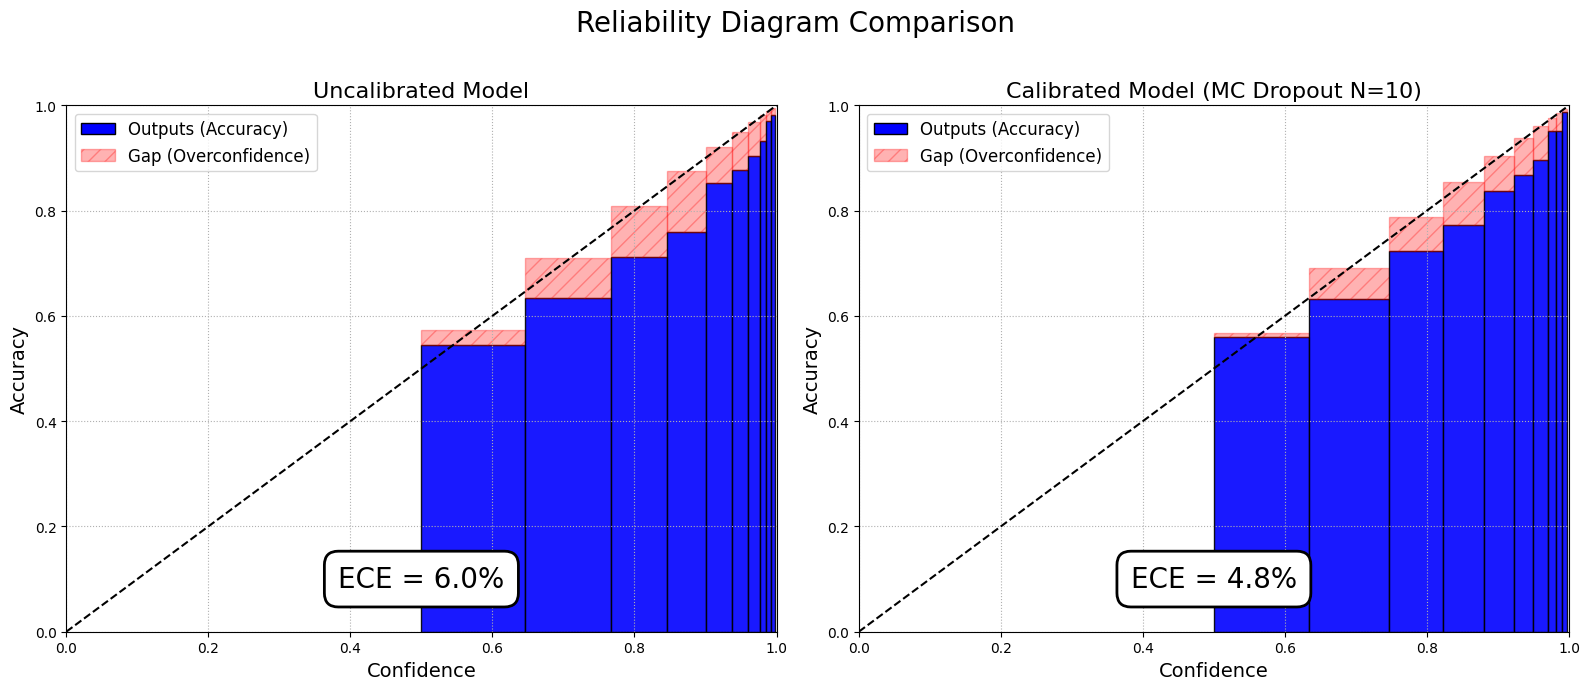

In [9]:
# --- 可视化1：可靠性图 (与TS方法对比) ---
# 使用MC Dropout的平均概率来评估校准效果
mc_probs_for_calib = mc_results['mean_probs']
y_true_for_calib = mc_results['labels']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# 绘制校准前的图 (与之前一样)
plot_reliability_diagram_final(axes[0], softmaxes.cpu().numpy(), y_true, "Uncalibrated Model")
# 绘制MC Dropout校准后的图
plot_reliability_diagram_final(axes[1], mc_probs_for_calib, y_true_for_calib, f"Calibrated Model (MC Dropout N={N_SAMPLES})")
plt.suptitle("Reliability Diagram Comparison", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

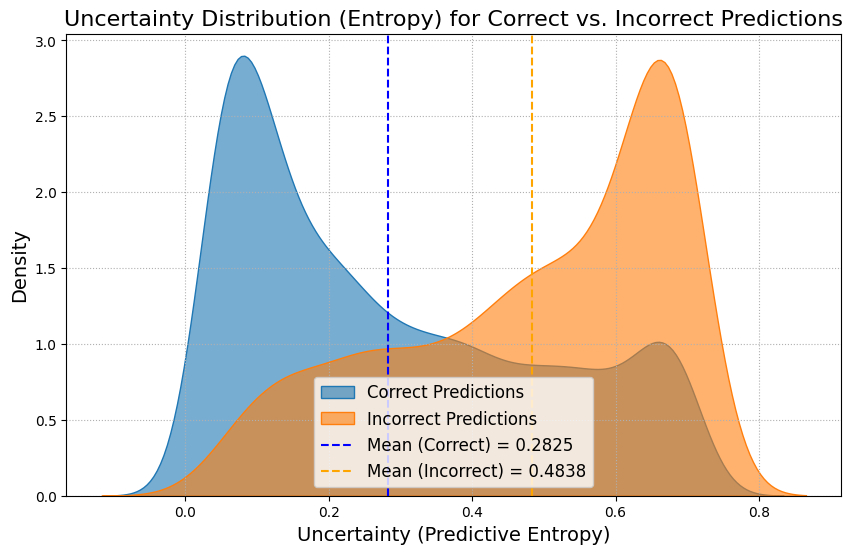

In [10]:
def calculate_predictive_entropy(probs):
    """计算预测熵"""
    # probs 形状: [n_samples, total_samples, n_classes]
    # 对每个样本的平均概率计算熵
    mean_probs = np.mean(probs, axis=0)
    # 加上一个很小的数epsilon防止log(0)
    epsilon = 1e-10
    entropy = -np.sum(mean_probs * np.log(mean_probs + epsilon), axis=1)
    return entropy

# --- 计算预测熵 ---
entropy_scores = calculate_predictive_entropy(mc_results['raw_probs'])
is_correct = mc_results['predictions'] == mc_results['labels']

# --- 绘制KDE图 (与之前类似，但X轴换为熵) ---
plt.figure(figsize=(10, 6))

sns.kdeplot(entropy_scores[is_correct], label='Correct Predictions', fill=True, alpha=0.6)
sns.kdeplot(entropy_scores[~is_correct], label='Incorrect Predictions', fill=True, alpha=0.6)

mean_entropy_correct = np.mean(entropy_scores[is_correct])
mean_entropy_incorrect = np.mean(entropy_scores[~is_correct])
plt.axvline(mean_entropy_correct, color='blue', linestyle='--', label=f'Mean (Correct) = {mean_entropy_correct:.4f}')
plt.axvline(mean_entropy_incorrect, color='orange', linestyle='--', label=f'Mean (Incorrect) = {mean_entropy_incorrect:.4f}')

plt.xlabel("Uncertainty (Predictive Entropy)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Uncertainty Distribution (Entropy) for Correct vs. Incorrect Predictions", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='dotted')
plt.show()

___
### 4 Conformal Prediction

In [11]:
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from src.uncertainty.conformal_prediction import get_softmax_outputs

# 确保 model, tokenizer, device 已经从之前的单元格加载好了
model.eval() # 确保模型在评估模式

# 获取验证集和测试集的Softmax输出
y_calib_probs, y_calib_true = get_softmax_outputs(val_data_loader, model, device)
y_test_probs, y_test_true = get_softmax_outputs(test_data_loader, model, device)

print("已成功获取校准集和测试集的Softmax输出。")

Getting softmax outputs: 100%|██████████| 156/156 [00:33<00:00,  4.70it/s]

已成功获取校准集和测试集的Softmax输出。


In [16]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from src import config # 确保config, model, tokenizer等已加载
from src.uncertainty.conformal_prediction import conformal_predict, evaluate_conformal, find_conformal_threshold

# --- 1. 准备数据 (与之前相同) ---
# 确保 y_calib_probs, y_calib_true (验证集) 和
# y_test_probs, y_test_true (测试集) 已经从之前的步骤中获取

print("数据已准备就绪。")
print(f"校准集 (Validation Set) 大小: {len(y_calib_true)} a")
print(f"测试集 (Test Set) 大小: {len(y_test_true)}")

# --- 2. 运行保形预测 ---
alpha = config.get_uq_param('conformal_alpha')  # 对应95%的置信度
print(f"\n开始进行保形预测 (置信度 = {1-alpha:.0%})...")
prediction_sets = conformal_predict(y_calib_probs, y_calib_true, y_test_probs, alpha)

# --- 3. 计算 q_hat ---
print(f"\n开始计算校准阈值 (置信度 = {1-alpha:.0%})...")
q_hat = find_conformal_threshold(model, val_data_loader, device, alpha)
print(f"保形预测的校准阈值 q_hat = {q_hat:.4f}")
# 保留四位小数四舍五入
short_q_hat = round(float(q_hat), 4)
# 更新参数列表
config.update_uq_params(conformal_q_hat=short_q_hat)

# --- 3. 评估结果 ---
coverage, avg_set_size = evaluate_conformal(y_test_true, prediction_sets)

print("\n" + "="*20 + " 保形预测评估结果 " + "="*20)
print(f"预设的置信度水平: {1-alpha:.2f}")
print(f"在测试集上的实际覆盖率: {coverage:.4f}")
print(f"在测试集上的平均预测集大小: {avg_set_size:.4f}")
print("="*64)

# 4. 查看一些预测结果示例
print("\n预测结果示例 (前5条):")
for i in range(5):
    class_names_in_set = {config.CLASS_NAMES[label] for label in prediction_sets[i]}
    print(f"  - 样本 {i}: 真实标签='{config.CLASS_NAMES[y_test_true[i]]}', "
          f"预测集={class_names_in_set}")

数据已准备就绪。
校准集 (Validation Set) 大小: 4990 a
测试集 (Test Set) 大小: 4991

开始进行保形预测 (置信度 = 95%)...


Generating Prediction Sets: 100%|██████████| 4991/4991 [00:00<00:00, 437185.88it/s]



开始计算校准阈值 (置信度 = 95%)...


Calibrating Conformal Threshold: 100%|██████████| 156/156 [00:33<00:00,  4.61it/s]

保形预测的校准阈值 q_hat = 0.9054
UQ parameters have been successfully updated.

==================== 保形预测评估结果 ====================
预设的置信度水平: 0.95
在测试集上的实际覆盖率: 0.9527
在测试集上的平均预测集大小: 1.4091

预测结果示例 (前5条):
  - 样本 0: 真实标签='negative', 预测集={'negative', 'positive'}
  - 样本 1: 真实标签='negative', 预测集={'negative', 'positive'}
  - 样本 2: 真实标签='negative', 预测集={'negative'}
  - 样本 3: 真实标签='positive', 预测集={'positive'}
  - 样本 4: 真实标签='negative', 预测集={'negative'}


/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) 

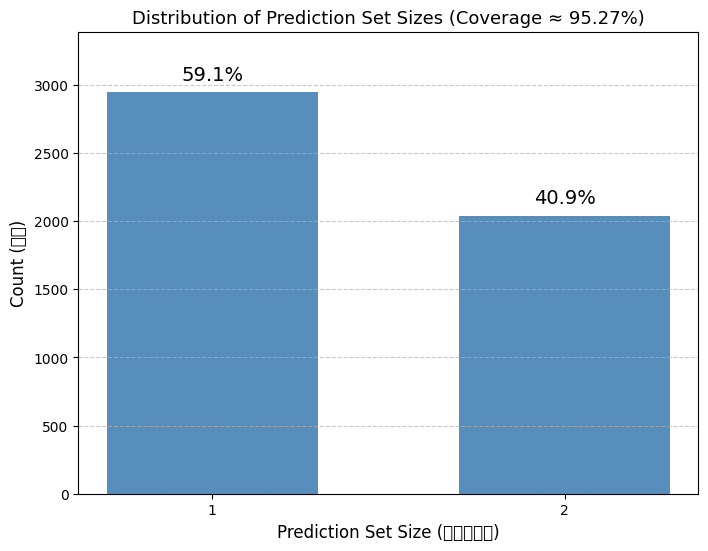

In [13]:
import matplotlib.pyplot as plt
import pandas as pd


# --- 确保 prediction_sets 和 coverage 变量已经从之前的单元格计算得出 ---

# 1. 计算每个预测集的大小
set_sizes = [len(s) for s in prediction_sets]

# 2. 统计不同大小的预测集的数量
size_counts = pd.Series(set_sizes).value_counts().sort_index()

# --- 3. 开始绘图 (再次优化版) ---
plt.figure(figsize=(8, 6)) 

bars = plt.bar(
    size_counts.index, 
    size_counts.values, 
    color='steelblue',
    width=0.6,
    alpha=0.9
)

plt.xlabel("Prediction Set Size (预测集大小)", fontsize=12)
plt.ylabel("Count (数量)", fontsize=12)
plt.title(f"Distribution of Prediction Set Sizes (Coverage ≈ {coverage:.2%})", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- 修改一：移除了 plt.box(False) 这一行，以保留完整的边框 ---

# 解决数字被遮挡的问题
total_samples = len(set_sizes)
y_max = size_counts.max()
plt.ylim(0, y_max * 1.15) 

# 在每个柱子上方显示百分比
for bar in bars:
    height = bar.get_height()
    percentage = f"{(height / total_samples) * 100:.1f}%"
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + (y_max * 0.02),
        percentage, 
        ha='center', 
        va='bottom', 
        fontsize=14
        # --- 修改二：移除了 fontweight='bold' 这个参数 ---
    )

plt.xticks(size_counts.index)

plt.show()

正在计算不同alpha值下的覆盖率...


100%|██████████| 25/25 [00:00<00:00, 84.97it/s]
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


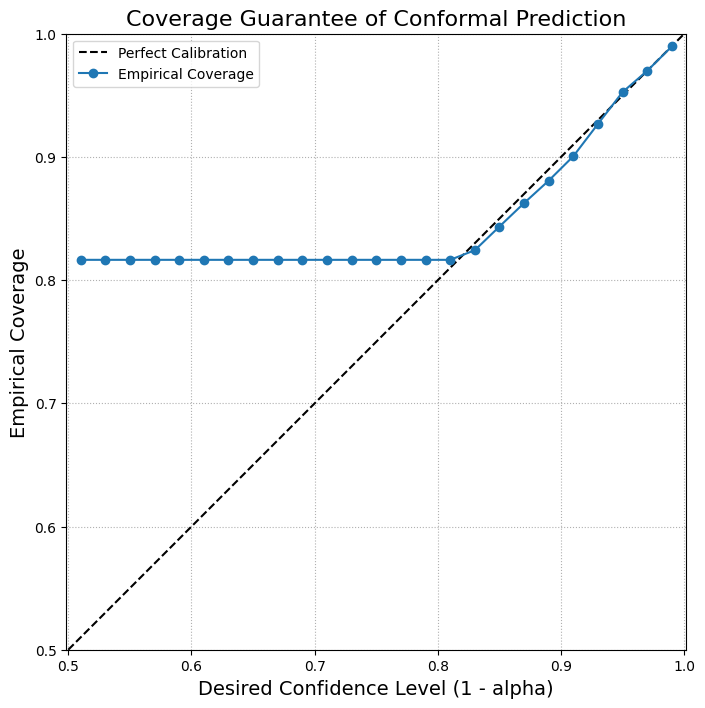

In [14]:
# --- 准备在一系列alpha值上进行测试 ---
alphas = np.arange(0.01, 0.5, 0.02)
actual_coverages = []

print("正在计算不同alpha值下的覆盖率...")
for alpha_level in tqdm(alphas):
    # 重新生成预测集
    temp_prediction_sets = conformal_predict(y_calib_probs, y_calib_true, y_test_probs, alpha=alpha_level)
    # 计算并记录覆盖率
    coverage, _ = evaluate_conformal(y_test_true, temp_prediction_sets)
    actual_coverages.append(coverage)

# 期望的置信度水平
desired_confidences = 1 - alphas

# --- 开始绘图 ---
plt.figure(figsize=(8, 8))
# 绘制y=x的完美对角线
plt.plot([0.5, 1], [0.5, 1], 'k--', label="Perfect Calibration")

# 绘制实际的曲线
plt.plot(desired_confidences, actual_coverages, 'o-', label="Empirical Coverage")

plt.xlabel("Desired Confidence Level (1 - alpha)", fontsize=14)
plt.ylabel("Empirical Coverage", fontsize=14)
plt.title("Coverage Guarantee of Conformal Prediction", fontsize=16)
plt.axis('equal') # 让x和y轴的比例相等，更直观
plt.xlim([0.5, 1])
plt.ylim([0.5, 1])
plt.legend()
plt.grid(True, linestyle='dotted')
plt.show()

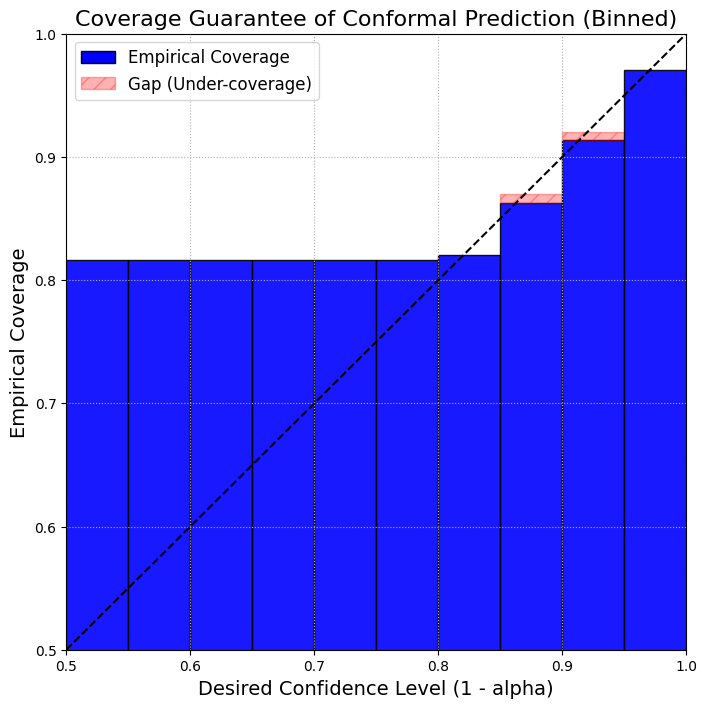

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 确保 desired_confidences 和 actual_coverages 已经从之前的单元格计算得出 ---

# --- 定义绘制新样式图表的函数 ---
def plot_coverage_guarantee_binned(ax, desired_confidences, actual_coverages, title):
    """
    以柱状图和Gap的形式绘制覆盖率保证图。
    """
    n_bins = 10
    # 我们只关注我们感兴趣的置信度范围，例如 0.5 到 1.0
    bin_boundaries = np.linspace(0.5, 1.0, n_bins + 1)
    
    ax.plot([0.5, 1], [0.5, 1], 'k--', zorder=2) # 绘制对角虚线

    for i in range(n_bins):
        # 找到落入当前箱内的数据点
        in_bin_mask = (desired_confidences >= bin_boundaries[i]) & (desired_confidences < bin_boundaries[i+1])
        
        if np.sum(in_bin_mask) > 0:
            # 计算箱内的平均期望置信度和平均实际覆盖率
            avg_desired_conf = np.mean(desired_confidences[in_bin_mask])
            avg_actual_coverage = np.mean(actual_coverages[in_bin_mask])
            
            bin_width = bin_boundaries[i+1] - bin_boundaries[i]
            bin_center = bin_boundaries[i] + bin_width / 2
            
            # 绘制蓝色柱子 (实际覆盖率)
            ax.bar(
                bin_center,
                avg_actual_coverage,
                width=bin_width,
                color='blue',
                edgecolor='black',
                alpha=0.9,
                zorder=1
            )
            
            # 绘制红色误差区域 (Gap)
            # Gap = 期望值 - 实际值。在这里我们只展示 Under-coverage 的情况
            gap = avg_desired_conf - avg_actual_coverage
            if gap > 0: # 只在实际覆盖率低于期望时显示Gap (Under-coverage)
                 ax.bar(
                    bin_center,
                    gap,
                    width=bin_width,
                    bottom=avg_actual_coverage,
                    color='red',
                    edgecolor='red',
                    alpha=0.3,
                    hatch='//',
                    zorder=1
                )

    ax.set_xlabel('Desired Confidence Level (1 - alpha)', fontsize=14)
    ax.set_ylabel('Empirical Coverage', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0.5, 1)
    ax.set_ylim(0.5, 1)
    ax.grid(True, linestyle='dotted')
    
    # 添加图例
    output_patch = mpatches.Patch(facecolor='blue', edgecolor='black', label='Empirical Coverage')
    gap_patch = mpatches.Patch(facecolor='red', edgecolor='red', alpha=0.3, hatch='//', label='Gap (Under-coverage)')
    ax.legend(handles=[output_patch, gap_patch], loc='upper left', fontsize=12)

# --- 创建图表并调用函数 ---
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

plot_coverage_guarantee_binned(
    ax,
    np.array(desired_confidences),
    np.array(actual_coverages),
    "Coverage Guarantee of Conformal Prediction (Binned)"
)

plt.show()